In [1]:
import time
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import torch
import pytorch3d.ops
from plyfile import PlyData, PlyElement
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
from argparse import ArgumentParser, Namespace
import cv2

from arguments import ModelParams, PipelineParams
from scene import Scene, GaussianModel, FeatureGaussianModel
from gaussian_renderer import render, render_contrastive_feature

from utils.sh_utils import SH2RGB

def get_combined_args(parser : ArgumentParser, model_path, target_cfg_file = None):
    cmdlne_string = ['--model_path', model_path]
    cfgfile_string = "Namespace()"
    args_cmdline = parser.parse_args(cmdlne_string)
    
    if target_cfg_file is None:
        if args_cmdline.target == 'seg':
            target_cfg_file = "seg_cfg_args"
        elif args_cmdline.target == 'scene' or args_cmdline.target == 'xyz':
            target_cfg_file = "cfg_args"
        elif args_cmdline.target == 'feature' or args_cmdline.target == 'coarse_seg_everything' or args_cmdline.target == 'contrastive_feature' :
            target_cfg_file = "feature_cfg_args"

    try:
        cfgfilepath = os.path.join(model_path, target_cfg_file)
        print("Looking for config file in", cfgfilepath)
        with open(cfgfilepath) as cfg_file:
            print("Config file found: {}".format(cfgfilepath))
            cfgfile_string = cfg_file.read()
    except TypeError:
        print("Config file found: {}".format(cfgfilepath))
        pass
    args_cfgfile = eval(cfgfile_string)

    merged_dict = vars(args_cfgfile).copy()
    for k,v in vars(args_cmdline).items():
        if v != None:
            merged_dict[k] = v

    return Namespace(**merged_dict)

# Hyper-parameters

In [2]:
import os
FEATURE_DIM = 32 # fixed

# MODEL_PATH = './output/lerf-fruit_aisle/'
MODEL_PATH = './output/garden' # 30000

FEATURE_GAUSSIAN_ITERATION = 10000

SCALE_GATE_PATH = os.path.join(MODEL_PATH, f'point_cloud/iteration_{str(FEATURE_GAUSSIAN_ITERATION)}/scale_gate.pt')

FEATURE_PCD_PATH = os.path.join(MODEL_PATH, f'point_cloud/iteration_{str(FEATURE_GAUSSIAN_ITERATION)}/contrastive_feature_point_cloud.ply')

# Data and Model Preparation


In [3]:
scale_gate = torch.nn.Sequential(
    torch.nn.Linear(1, 32, bias=True),
    torch.nn.Sigmoid()
)

scale_gate.load_state_dict(torch.load(SCALE_GATE_PATH))
scale_gate = scale_gate.cuda()

parser = ArgumentParser(description="Testing script parameters")
model = ModelParams(parser, sentinel=True)
pipeline = PipelineParams(parser)
parser.add_argument('--target', default='scene', type=str)

args = get_combined_args(parser, MODEL_PATH)

dataset = model.extract(args)

# If use language-driven segmentation, load clip feature and original masks
dataset.need_features = True

# To obtain mask scales
dataset.need_masks = True

scene_gaussians = GaussianModel(dataset.sh_degree)

feature_gaussians = FeatureGaussianModel(FEATURE_DIM)
scene = Scene(dataset, scene_gaussians, feature_gaussians, load_iteration=-1, feature_load_iteration=FEATURE_GAUSSIAN_ITERATION, shuffle=False, mode='eval', target='contrastive_feature')


Looking for config file in ./output/garden/cfg_args
Config file found: ./output/garden/cfg_args
Loading trained model at iteration 30000, 10000
Allow Camera Principle Point Shift: False
Reading camera 185/185
Loading Training Cameras
Loading Test Cameras


In [4]:
from sklearn.preprocessing import QuantileTransformer
# Borrowed from GARField, but modified
def get_quantile_func(scales: torch.Tensor, distribution="normal"):
    """
    Use 3D scale statistics to normalize scales -- use quantile transformer.
    """
    scales = scales.flatten()

    scales = scales.detach().cpu().numpy()
    print(scales.max(), '?')

    # Calculate quantile transformer
    quantile_transformer = QuantileTransformer(output_distribution=distribution)
    quantile_transformer = quantile_transformer.fit(scales.reshape(-1, 1))

    
    def quantile_transformer_func(scales):
        scales_shape = scales.shape

        scales = scales.reshape(-1,1)
        
        return torch.Tensor(
            quantile_transformer.transform(scales.detach().cpu().numpy())
        ).to(scales.device).reshape(scales_shape)

    return quantile_transformer_func, quantile_transformer
    
all_scales = []
for cam in scene.getTrainCameras():
    all_scales.append(cam.mask_scales)
all_scales = torch.cat(all_scales)

upper_bound_scale = all_scales.max().item()
# upper_bound_scale = np.percentile(all_scales.detach().cpu().numpy(), 75)

# all_scales = []
# for cam in scene.getTrainCameras():
#     cam.mask_scales = torch.clamp(cam.mask_scales, 0, upper_bound_scale).detach()
#     all_scales.append(cam.mask_scales)
# all_scales = torch.cat(all_scales)

# quantile transformer
q_trans, q_trans_ = get_quantile_func(all_scales, 'uniform')

42.626877 ?


In [5]:
all_scales.max()

tensor(42.6269, grad_fn=<MaxBackward1>)

In [6]:
# For saving the normal q_trans, if the q_trans is uniform, we don't have to save it

# from joblib import dump, load
# dump(q_trans_, 'quantile_trans_test.jl')
# a = load('quantile_trans_test.jl')

In [7]:
upper_bound_scale

42.62687683105469

In [8]:
q_trans(torch.Tensor([70]))

tensor([1.])

# Begin Segmenting

In [9]:
from copy import deepcopy
cameras = scene.getTrainCameras()
print("There are",len(cameras),"views in the dataset.")
print(upper_bound_scale)

There are 185 views in the dataset.
42.62687683105469


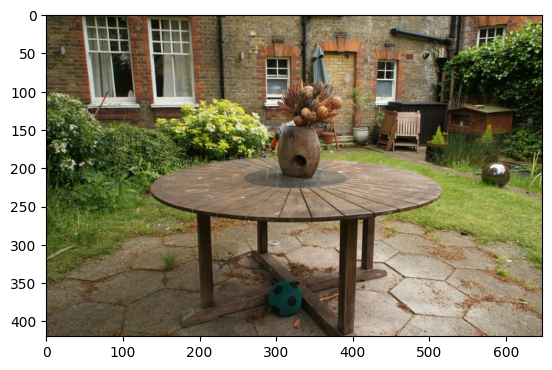

In [10]:
ref_img_camera_id = 17
mask_img_camera_id = 0

view = deepcopy(cameras[ref_img_camera_id])

view.feature_height, view.feature_width = view.image_height, view.image_width
img = view.original_image * 255
img = img.permute([1,2,0]).detach().cpu().numpy().astype(np.uint8)

bg_color = [0 for i in range(FEATURE_DIM)]
background = torch.tensor(bg_color, dtype=torch.float32, device="cuda")
rendered_feature = render_contrastive_feature(view, feature_gaussians, pipeline.extract(args), background, norm_point_features=True, smooth_type = None)['render']
feature_h, feature_w = rendered_feature.shape[-2:]


plt.imshow(img)

# Point Prompt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


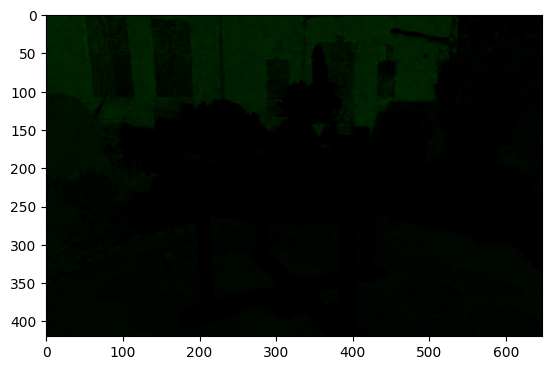

In [11]:
with torch.no_grad():
    # If the q_trans is normal
    # scale = 2.
    # scale = torch.full((1,), scale).cuda()
    # scale = q_trans(scale)

    # If the q_trans is uniform, the scale can be any value between 0 and 1
    # scale = torch.tensor([0]).cuda()
    # scale = torch.tensor([0.5]).cuda()
    scale = torch.tensor([1.]).cuda()

    gates = scale_gate(scale)

    feature_with_scale = rendered_feature
    feature_with_scale = feature_with_scale * gates.unsqueeze(-1).unsqueeze(-1)
    scale_conditioned_feature = feature_with_scale.permute([1,2,0])

    plt.imshow(scale_conditioned_feature[:,:,:3].detach().cpu().numpy())

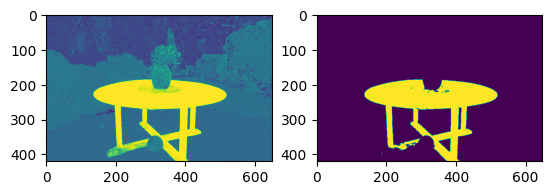

In [12]:
query_index = (200, 250)

query_index = (
    int(query_index[0] / view.image_height * view.feature_height),
    int(query_index[1] / view.image_width * view.feature_width),
               )

normed_features = torch.nn.functional.normalize(scale_conditioned_feature, dim = -1, p = 2)
query_feature = normed_features[query_index[0], query_index[1]]

similarity = torch.einsum('C,HWC->HW', query_feature, normed_features)

plt.subplot(1,2,1)
plt.imshow(similarity.detach().cpu().numpy())
plt.subplot(1,2,2)
plt.imshow(similarity.detach().cpu().numpy() > 0.75)

# Segmentation in 3D

After obtaining query features, we can use it to segment objects in 3D.

In [13]:
point_features = feature_gaussians.get_point_features

scale_conditioned_point_features = point_features * gates.unsqueeze(0)


In [14]:
normed_scale_conditioned_point_features = torch.nn.functional.normalize(scale_conditioned_point_features, dim = -1, p = 2)

similarities = torch.einsum('C,NC->N', query_feature.cuda(), normed_scale_conditioned_point_features)

similarities[similarities < 0.5] = 0

In [15]:
bg_color = [0 for i in range(FEATURE_DIM)]
background = torch.tensor(bg_color, dtype=torch.float32, device="cuda")
rendered_similarities = render(cameras[5], scene_gaussians, pipeline.extract(args), background, override_color=similarities.unsqueeze(-1).repeat([1,3]))['render']

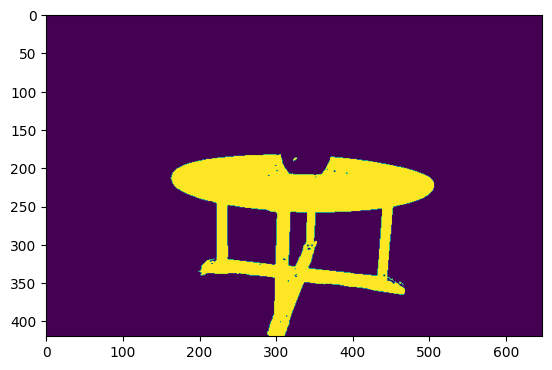

In [16]:
plt.imshow(rendered_similarities.permute([1,2,0])[:,:,0].detach().cpu() > 0.6)

In [17]:
try:
    scene_gaussians.roll_back()
except:
    pass
scene_gaussians.segment(similarities > 0.75)

In [18]:
sim = similarities > 0.75
print(sim[:-10])

tensor([False, False, False,  ..., False, False, False], device='cuda:0')


In [19]:
# save the segmentation
name = 'precomputed_mask'
import os
os.makedirs('./segmentation_res', exist_ok=True)
torch.save(similarities > 0.75, f'./segmentation_res/{name}.pt')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


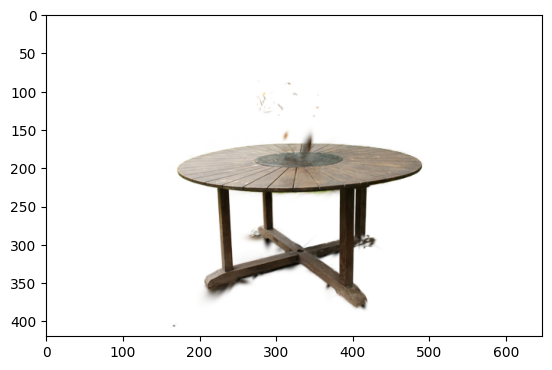

In [20]:
bg_color = [1 for i in range(FEATURE_DIM)]
background = torch.tensor(bg_color, dtype=torch.float32, device="cuda")
rendered_segmented_image = render(cameras[0], scene_gaussians, pipeline.extract(args), background)['render']
plt.imshow(rendered_segmented_image.permute([1,2,0]).detach().cpu())

In [21]:
scene_gaussians.roll_back()

# Cluster in 3D

In [22]:
point_features = feature_gaussians.get_point_features

scale_conditioned_point_features = torch.nn.functional.normalize(point_features, dim = -1, p = 2) * gates.unsqueeze(0)

normed_point_features = torch.nn.functional.normalize(scale_conditioned_point_features, dim = -1, p = 2)

sampled_point_features = scale_conditioned_point_features[torch.rand(scale_conditioned_point_features.shape[0]) > 0.98]

normed_sampled_point_features = sampled_point_features / torch.norm(sampled_point_features, dim = -1, keepdim = True)

print(len(sampled_point_features))

67778


In [23]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=10, cluster_selection_epsilon=0.01)

cluster_labels = clusterer.fit_predict(normed_sampled_point_features.detach().cpu().numpy())
print(np.unique(cluster_labels))

cluster_centers = torch.zeros(len(np.unique(cluster_labels))-1, normed_sampled_point_features.shape[-1])
for i in range(1, len(np.unique(cluster_labels))):
    cluster_centers[i-1] = torch.nn.functional.normalize(normed_sampled_point_features[cluster_labels == i-1].mean(dim = 0), dim = -1)

/userhome/30/varshney/anaconda3/envs/sugar/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/userhome/30/varshney/anaconda3/envs/sugar/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46
 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70
 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90]


In [24]:
seg_score = torch.einsum('nc,bc->bn', cluster_centers.cpu(), normed_point_features.cpu())

In [25]:
label_to_color = np.random.rand(1000, 3)
point_colors = label_to_color[seg_score.argmax(dim = -1).cpu().numpy()]
point_colors[seg_score.max(dim = -1)[0].detach().cpu().numpy() < 0.5] = (0,0,0)

In [26]:
try:
    scene_gaussians.roll_back()
except:
    pass

In [27]:
bg_color = [0 for i in range(FEATURE_DIM)]
background = torch.tensor(bg_color, dtype=torch.float32, device="cuda")

rendered_seg_map = render(cameras[0], scene_gaussians, pipeline.extract(args), background, override_color=torch.from_numpy(point_colors).cuda().float())['render']

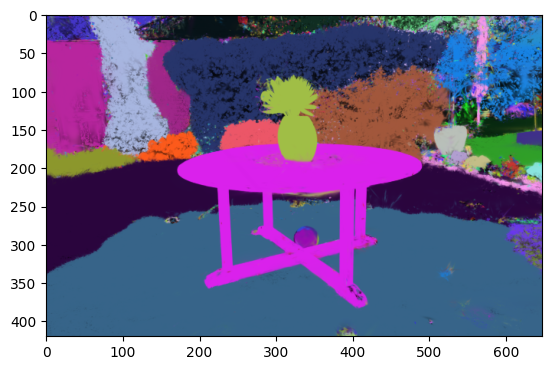

In [28]:
plt.imshow(rendered_seg_map.permute([1,2,0]).detach().cpu().numpy())

In [30]:
positions = scene_gaussians.get_xyz

# Get unique cluster IDs (excluding background points with low scores)
cluster_mask = seg_score.max(dim=-1)[0] >= 0.5
cluster_ids = seg_score.argmax(dim=-1)[cluster_mask]
unique_clusters = torch.unique(cluster_ids)

# Calculate centroids for each cluster
cluster_centroids = {}
centroid_positions = []
centroid_colors = []

for cluster_id in unique_clusters:
    # Find all points belonging to this cluster
    points_in_cluster = positions[
        (seg_score.argmax(dim=-1) == cluster_id) & 
        (seg_score.max(dim=-1)[0] >= 0.5)
    ]
    
    # Calculate centroid as mean position
    if len(points_in_cluster) > 0:
        centroid = points_in_cluster.mean(dim=0)
        cluster_centroids[cluster_id.item()] = centroid.detach().cpu().numpy()
        
        # Store centroid position and assign a color (using the same color as the cluster)
        centroid_positions.append(centroid.detach().cpu().numpy())
        centroid_colors.append(label_to_color[cluster_id.item()])
        
        # Print cluster information
        print(f"Cluster {cluster_id.item()}: {len(points_in_cluster)} points, centroid at {centroid.detach().cpu().numpy()}")

Cluster 0: 1898 points, centroid at [-2.8539236  1.1292748  1.2923545]
Cluster 1: 2437 points, centroid at [-3.7999117  1.7824724  1.8396627]
Cluster 2: 2545 points, centroid at [ 4.0782976 -0.9827384  5.9312468]
Cluster 3: 4735 points, centroid at [ 2.638535   3.8007529 -3.6261256]
Cluster 4: 1946 points, centroid at [16.305523 -5.740095  9.846151]
Cluster 5: 2432 points, centroid at [5.5242896  0.15413152 4.898776  ]
Cluster 6: 4419 points, centroid at [ 6.1769314 -0.6623741  2.5442717]
Cluster 7: 5545 points, centroid at [ 8.612503  -1.2512262  0.3422666]
Cluster 8: 4105 points, centroid at [-2.1750898  -0.54384065  4.4173155 ]
Cluster 9: 3260 points, centroid at [11.683744  -1.7298331  5.306632 ]
Cluster 10: 3508 points, centroid at [13.339489  -2.0651684  6.0435376]
Cluster 11: 5209 points, centroid at [ 1.9610032  2.6246495 -2.10132  ]
Cluster 12: 6962 points, centroid at [ 3.4657326 -3.3173833  3.8210657]
Cluster 13: 4273 points, centroid at [ 1.3670874  1.9607317 -0.5026645]
Cl

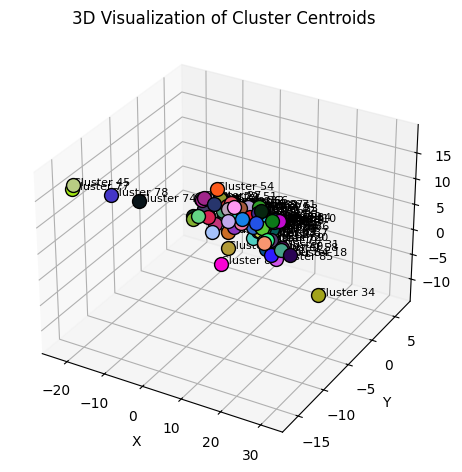

In [32]:
# Simple 3D visualization of just the centroids
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the centroids
for i, pos in enumerate(centroid_positions):
    color = centroid_colors[i]
    ax.scatter(pos[0], pos[1], pos[2], c=[color], s=100, marker='o', edgecolor='black')
    ax.text(pos[0], pos[1], pos[2], f'Cluster {unique_clusters[i].item()}', size=8)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Visualization of Cluster Centroids')

plt.tight_layout()
plt.show()

# Cluster in 2D

In [33]:
downsampled_features = torch.nn.functional.interpolate(scale_conditioned_feature.permute([2,0,1]).unsqueeze(0), (128, 128), mode = 'bilinear').squeeze()
cluster_normed_features = torch.nn.functional.normalize(downsampled_features, dim = 0, p = 2).permute([1,2,0])

In [34]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=10, cluster_selection_epsilon=0.01)
cluster_labels = clusterer.fit_predict(cluster_normed_features.reshape([-1, cluster_normed_features.shape[-1]]).detach().cpu().numpy())
labels = cluster_labels.reshape([cluster_normed_features.shape[0], cluster_normed_features.shape[1]])
print(np.unique(labels))

cluster_centers = torch.zeros(len(np.unique(labels))-1, cluster_normed_features.shape[-1])
for i in range(1, len(np.unique(labels))):
    cluster_centers[i-1] = torch.nn.functional.normalize(cluster_normed_features[labels == i-1].mean(dim = 0), dim = -1)

/userhome/30/varshney/anaconda3/envs/sugar/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/userhome/30/varshney/anaconda3/envs/sugar/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40]


In [35]:
label_to_color = np.random.rand(200, 3)
segmentation_res = torch.einsum('nc,hwc->hwn', cluster_centers.cuda(), normed_features)

segmentation_res_idx = segmentation_res.argmax(dim = -1)
colored_labels = label_to_color[segmentation_res_idx.cpu().numpy().astype(np.int8)]

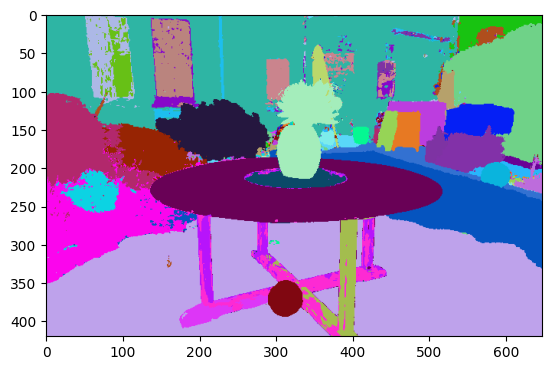

In [36]:
plt.imshow(colored_labels)

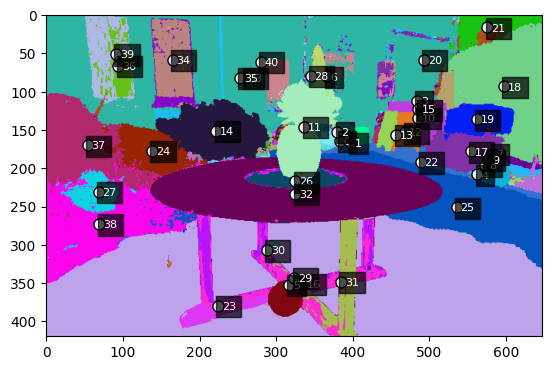

Cluster 0: Centroid at (383, 164)
Cluster 1: Centroid at (398, 167)
Cluster 2: Centroid at (380, 152)
Cluster 3: Centroid at (484, 112)
Cluster 4: Centroid at (563, 208)
Cluster 5: Centroid at (317, 352)
Cluster 6: Centroid at (366, 80)
Cluster 7: Centroid at (583, 181)
Cluster 8: Centroid at (573, 196)
Cluster 9: Centroid at (577, 189)
Cluster 10: Centroid at (485, 134)
Cluster 11: Centroid at (337, 146)
Cluster 12: Centroid at (469, 153)
Cluster 13: Centroid at (457, 156)
Cluster 14: Centroid at (222, 151)
Cluster 15: Centroid at (486, 123)
Cluster 16: Centroid at (335, 351)
Cluster 17: Centroid at (554, 178)
Cluster 18: Centroid at (598, 93)
Cluster 19: Centroid at (562, 136)
Cluster 20: Centroid at (493, 58)
Cluster 21: Centroid at (576, 16)
Cluster 22: Centroid at (489, 192)
Cluster 23: Centroid at (224, 380)
Cluster 24: Centroid at (138, 177)
Cluster 25: Centroid at (536, 251)
Cluster 26: Centroid at (325, 217)
Cluster 27: Centroid at (68, 231)
Cluster 28: Centroid at (345, 79)
C

In [37]:
# Find centroids for 2D clusters
cluster_centers_coords = []
cluster_ids = []

# Process each cluster
for i in range(len(cluster_centers)):
    # Create binary mask for this cluster
    cluster_mask = (segmentation_res_idx == i).cpu().numpy()
    
    # Skip empty clusters
    if not cluster_mask.any():
        continue
        
    # Find all coordinates (y, x) where this cluster exists
    y_coords, x_coords = np.where(cluster_mask)
    
    # Calculate centroid as average position
    centroid_y = int(np.mean(y_coords))
    centroid_x = int(np.mean(x_coords))
    
    cluster_centers_coords.append((centroid_x, centroid_y))
    cluster_ids.append(i)

# First show the colored cluster image
plt.imshow(colored_labels)

# Then overlay centroids as points
for i, (x, y) in enumerate(cluster_centers_coords):
    plt.plot(x, y, 'o', color='white', markersize=8, markeredgecolor='black')
    plt.text(x+5, y+5, f"{cluster_ids[i]}", color='white', 
             fontsize=8, bbox=dict(facecolor='black', alpha=0.7))
plt.show()

# Print centroid coordinates
for i, coord in enumerate(cluster_centers_coords):
    print(f"Cluster {cluster_ids[i]}: Centroid at {coord}")

In [38]:
for i in range(len(cluster_centers_coords)):
    query_index = cluster_centers_coords[i][::-1]
    print(i, query_index)

    normed_features = torch.nn.functional.normalize(scale_conditioned_feature, dim = -1, p = 2)
    query_feature = normed_features[query_index[0], query_index[1]]

    similarity = torch.einsum('C,HWC->HW', query_feature, normed_features)

    point_features = feature_gaussians.get_point_features

    scale_conditioned_point_features = point_features * gates.unsqueeze(0)

    normed_scale_conditioned_point_features = torch.nn.functional.normalize(scale_conditioned_point_features, dim = -1, p = 2)

    similarities = torch.einsum('C,NC->N', query_feature.cuda(), normed_scale_conditioned_point_features)

    similarities[similarities < 0.5] = 0
    bg_color = [0 for i in range(FEATURE_DIM)]
    background = torch.tensor(bg_color, dtype=torch.float32, device="cuda")
    rendered_similarities = render(cameras[5], scene_gaussians, pipeline.extract(args), background, override_color=similarities.unsqueeze(-1).repeat([1,3]))['render']

    name = f'precomputed_mask_{i}'

    plt.imsave(f'./segmentation_res/{name}.png', rendered_similarities.permute([1,2,0])[:,:,0].detach().cpu() > 0.4)

    import os
    os.makedirs('./segmentation_res', exist_ok=True)
    torch.save(similarities > 0.75, f'./segmentation_res/{name}.pt')


0 (164, 383)
1 (167, 398)
2 (152, 380)
3 (112, 484)
4 (208, 563)
5 (352, 317)
6 (80, 366)
7 (181, 583)
8 (196, 573)
9 (189, 577)
10 (134, 485)
11 (146, 337)
12 (153, 469)
13 (156, 457)
14 (151, 222)
15 (123, 486)
16 (351, 335)
17 (178, 554)
18 (93, 598)
19 (136, 562)
20 (58, 493)
21 (16, 576)
22 (192, 489)
23 (380, 224)
24 (177, 138)
25 (251, 536)
26 (217, 325)
27 (231, 68)
28 (79, 345)
29 (343, 324)
30 (307, 288)
31 (348, 385)
32 (233, 325)
33 (82, 259)
34 (58, 165)
35 (82, 253)
36 (66, 94)
37 (170, 54)
38 (273, 69)
39 (51, 91)
40 (61, 280)
